# Import

In [1]:
#pip install numpy==1.26.4

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


from PIL import Image
import os
from os import listdir
import time
import functools

from sklearn import manifold, decomposition
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, auc, roc_auc_score, roc_curve
from glob import glob


import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50V2, NASNetMobile
from tensorflow.keras.applications import vgg16, resnet_v2, nasnet
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalAveragePooling1D, Flatten, Dense, Dropout 
from tensorflow.keras.layers import Rescaling, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical

2025-04-03 10:58:13.009762: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-03 10:58:13.014089: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-03 10:58:13.025425: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743663493.044455  494738 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743663493.050009  494738 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743663493.065347  494738 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [3]:
from sklearn import preprocessing
import cv2
from sklearn import cluster, metrics
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from matplotlib.image import imread

In [4]:
cv2.__version__

'4.11.0'

In [5]:
#import utils.UVA as UVA
#import utils.MVA as MVA
#import utils.PCA as PCA

In [6]:
# load csv

df = pd.read_csv('data/flipkart_updated_1.csv')

df.shape

(1050, 9)

# Vérification données

In [7]:
df.head(3)

,uniq_id,product_name,product_category_tree,image,description,brand,cat_1,cat_2,cat_3
0,55b85ea15a1536d46b7190ad6fff8ce7,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",55b85ea15a1536d46b7190ad6fff8ce7.jpg,Key Features of Elegance Polyester Multicolor ...,Elegance,Home Furnishing,Curtains & Accessories,Curtains
1,7b72c92c2f6c40268628ec5f14c6d590,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",7b72c92c2f6c40268628ec5f14c6d590.jpg,Specifications of Sathiyas Cotton Bath Towel (...,Sathiyas,Baby Care,Baby Bath & Skin,Baby Bath Towels
2,64d5d4a258243731dc7bbb1eef49ad74,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",64d5d4a258243731dc7bbb1eef49ad74.jpg,Key Features of Eurospa Cotton Terry Face Towe...,Eurospa,Baby Care,Baby Bath & Skin,Baby Bath Towels


In [8]:
#df['image'] = df['image'].apply(lambda x: "data/Images/" + str(x))
#df.head(3)

path = 'data/Images/'

In [9]:
def show_cat_img(df, path, cat, img_qt):
    grouped = df.groupby(cat).head(img_qt)
        
    for category, group in grouped.groupby(cat):
        print(f"Catégorie: {category}")
        plt.figure(figsize=(4, 2))
        for idx, (i, row) in enumerate(group.iterrows()):
            image_path = path + row['image']
            if os.path.exists(image_path):
                img = Image.open(image_path)
                plt.subplot(1, img_qt, idx + 1)  # Utiliser idx + 1 pour s'assurer que l'index est correct
                plt.imshow(img)
                plt.axis('off')
            else:
                print(f"Image non trouvée: {image_path}")
        plt.show()

Catégorie: Baby Care


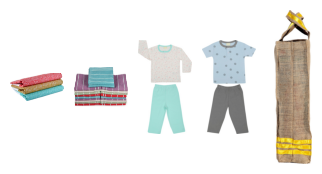

Catégorie: Beauty and Personal Care


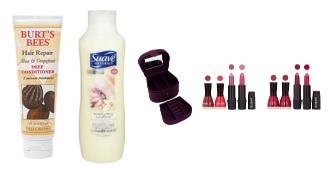

Catégorie: Computers


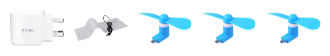

Catégorie: Home Decor & Festive Needs


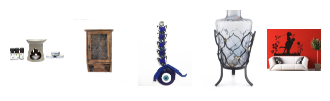

Catégorie: Home Furnishing


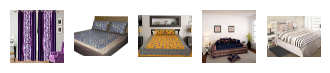

Catégorie: Kitchen & Dining


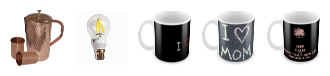

Catégorie: Watches


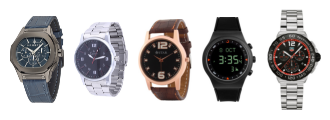

In [10]:
show_cat_img(df, path, 'cat_1', 5)

# Modèle SIFT

In [11]:
df_label = df[['image', 'description','cat_1']].copy()

le = preprocessing.LabelEncoder()
df_label["label"] = le.fit_transform(df_label["cat_1"])

df_label

,image,description,cat_1,label
0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,Key Features of Elegance Polyester Multicolor ...,Home Furnishing,4
1,7b72c92c2f6c40268628ec5f14c6d590.jpg,Specifications of Sathiyas Cotton Bath Towel (...,Baby Care,0
2,64d5d4a258243731dc7bbb1eef49ad74.jpg,Key Features of Eurospa Cotton Terry Face Towe...,Baby Care,0
3,d4684dcdc759dd9cdf41504698d737d8.jpg,Key Features of SANTOSH ROYAL FASHION Cotton P...,Home Furnishing,4
4,6325b6870c54cd47be6ebfbffa620ec7.jpg,Key Features of Jaipur Print Cotton Floral Kin...,Home Furnishing,4
...,...,...,...,...
1045,958f54f4c46b53c8a0a9b8167d9140bc.jpg,Oren Empower Extra Large Self Adhesive Sticker...,Baby Care,0
1046,fd6cbcc22efb6b761bd564c28928483c.jpg,Wallmantra Large Vinyl Sticker Sticker (Pack o...,Baby Care,0
1047,5912e037d12774bb73a2048f35a00009.jpg,Buy Uberlyfe Extra Large Pigmented Polyvinyl F...,Baby Care,0
1048,c3edc504d1b4f0ba6224fa53a43a7ad6.jpg,Buy Wallmantra Medium Vinyl Sticker Sticker fo...,Baby Care,0


In [12]:
df_label['cat_1'].unique()

array(['Home Furnishing', 'Baby Care', 'Watches',
       'Home Decor & Festive Needs', 'Kitchen & Dining',
       'Beauty and Personal Care', 'Computers'], dtype=object)

In [13]:
df_label

,image,description,cat_1,label
0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,Key Features of Elegance Polyester Multicolor ...,Home Furnishing,4
1,7b72c92c2f6c40268628ec5f14c6d590.jpg,Specifications of Sathiyas Cotton Bath Towel (...,Baby Care,0
2,64d5d4a258243731dc7bbb1eef49ad74.jpg,Key Features of Eurospa Cotton Terry Face Towe...,Baby Care,0
3,d4684dcdc759dd9cdf41504698d737d8.jpg,Key Features of SANTOSH ROYAL FASHION Cotton P...,Home Furnishing,4
4,6325b6870c54cd47be6ebfbffa620ec7.jpg,Key Features of Jaipur Print Cotton Floral Kin...,Home Furnishing,4
...,...,...,...,...
1045,958f54f4c46b53c8a0a9b8167d9140bc.jpg,Oren Empower Extra Large Self Adhesive Sticker...,Baby Care,0
1046,fd6cbcc22efb6b761bd564c28928483c.jpg,Wallmantra Large Vinyl Sticker Sticker (Pack o...,Baby Care,0
1047,5912e037d12774bb73a2048f35a00009.jpg,Buy Uberlyfe Extra Large Pigmented Polyvinyl F...,Baby Care,0
1048,c3edc504d1b4f0ba6224fa53a43a7ad6.jpg,Buy Wallmantra Medium Vinyl Sticker Sticker fo...,Baby Care,0


In [14]:
df_label['label'].unique()

array([4, 0, 6, 3, 5, 1, 2])

## Pre-processing images : réduction de taille de fichiers

In [15]:
path = 'data/Images/'
new_path = 'data/Images_process/'

In [16]:
def preprocess_image(image, max_size=255):
    # Redimensionner l'image tout en conservant le ratio d'aspect
    height, width = image.shape
    if height > width:
        if height > max_size:
            scale = max_size / height
            new_width = int(width * scale)
            image = cv2.resize(image, (new_width, max_size))
    else:
        if width > max_size:
            scale = max_size / width
            new_height = int(height * scale)
            image = cv2.resize(image, (max_size, new_height))

    return image

In [17]:
def preprocess_folder(path, max_size):
    # Créer le répertoire de sortie s'il n'existe pas
    os.makedirs(new_path, exist_ok=True)
    
    # Appliquer le prétraitement et sauvegarder les images
    for index, row in df_label.iterrows():
        image_path = os.path.join(path, row['image'])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
        if image is not None:
            preprocessed_image = preprocess_image(image)
    
            # Sauvegarder l'image prétraitée
            new_image_path = os.path.join(new_path, row['image'])
            cv2.imwrite(new_image_path, (preprocessed_image * max_size).astype(np.uint8))
            print(f"Image sauvegardée: {new_image_path}")
        else:
            print(f"Image non trouvée: {image_path}")

In [18]:
def preprocess_folder(path, new_path, max_size):
    # Créer le répertoire de sortie s'il n'existe pas
    os.makedirs(new_path, exist_ok=True)

    # Appliquer le prétraitement et sauvegarder les images
    for index, row in df_label.iterrows():
        image_path = os.path.join(path, row['image'])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if image is not None:
            preprocessed_image = preprocess_image(image, max_size)

            # Sauvegarder l'image prétraitée
            new_image_path = os.path.join(new_path, row['image'])
            cv2.imwrite(new_image_path, preprocessed_image)
            print(f"Image sauvegardée: {new_image_path}")
        else:
            print(f"Image non trouvée: {image_path}")

In [19]:
preprocess_folder(path, new_path, max_size=255)

Image sauvegardée: data/Images_process/55b85ea15a1536d46b7190ad6fff8ce7.jpg
Image sauvegardée: data/Images_process/7b72c92c2f6c40268628ec5f14c6d590.jpg
Image sauvegardée: data/Images_process/64d5d4a258243731dc7bbb1eef49ad74.jpg
Image sauvegardée: data/Images_process/d4684dcdc759dd9cdf41504698d737d8.jpg
Image sauvegardée: data/Images_process/6325b6870c54cd47be6ebfbffa620ec7.jpg
Image sauvegardée: data/Images_process/893aa5ed55f7cff2eccea7758d7a86bd.jpg
Image sauvegardée: data/Images_process/f355cc1ccb08bd0d283ed979b7ee7515.jpg
Image sauvegardée: data/Images_process/dd0e3470a7e6ed76fd69c2da27721041.jpg
Image sauvegardée: data/Images_process/41384da51732c0b4df3de8f395714fbb.jpg
Image sauvegardée: data/Images_process/710ed5f2393a4b9e8823aa0029f71f93.jpg
Image sauvegardée: data/Images_process/920154acbe49d3202ed7d2ed2df1ea13.jpg
Image sauvegardée: data/Images_process/08452abdadb3db1e686b94a9c52fc7b6.jpg
Image sauvegardée: data/Images_process/1e8741b5ae27a513546c94b3f3312aee.jpg
Image sauveg

In [20]:
def get_directory_size(directory):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(directory):
        for filename in filenames:
            file_path = os.path.join(dirpath, filename)
            # Ajouter la taille du fichier à la taille totale
            total_size += os.path.getsize(file_path)
    return total_size

# Chemins des répertoires
path = 'data/Images/'
new_path = 'data/Images_process/'

# Obtenir la taille totale des répertoires
original_size_bytes = get_directory_size(path)
processed_size_bytes = get_directory_size(new_path)

# Convertir en kilo-octets (KB) et méga-octets (MB)
original_size_kb = original_size_bytes / 1024
processed_size_kb = processed_size_bytes / 1024

original_size_mb = original_size_kb / 1024
processed_size_mb = processed_size_kb / 1024

# Afficher les tailles
print(f"Taille totale du répertoire original: {original_size_kb:.2f} KB ({original_size_mb:.2f} MB)")
print(f"Taille totale du répertoire traité: {processed_size_kb:.2f} KB ({processed_size_mb:.2f} MB)")

# Comparaison
size_difference_kb = original_size_kb - processed_size_kb
size_difference_mb = size_difference_kb / 1024
print(f"Différence de taille: {size_difference_kb:.2f} KB ({size_difference_mb:.2f} MB)")

Taille totale du répertoire original: 357305.14 KB (348.93 MB)
Taille totale du répertoire traité: 17519.48 KB (17.11 MB)
Différence de taille: 339785.66 KB (331.82 MB)


In [21]:
def get_file_sizes(directory):
    file_sizes = []
    for filename in os.listdir(directory):
        file_path = os.path.join(directory, filename)
        if os.path.isfile(file_path):
            # Taille en octets
            size_bytes = os.path.getsize(file_path)

            # Lire l'image pour obtenir les dimensions en pixels
            image = cv2.imread(file_path)
            if image is not None:
                height, width = image.shape[:2]
                size_pixels = width * height
            else:
                size_pixels = None

            file_sizes.append({
                'filename': filename,
                'size_bytes': size_bytes,
                'size_pixels': size_pixels
            })
    return file_sizes

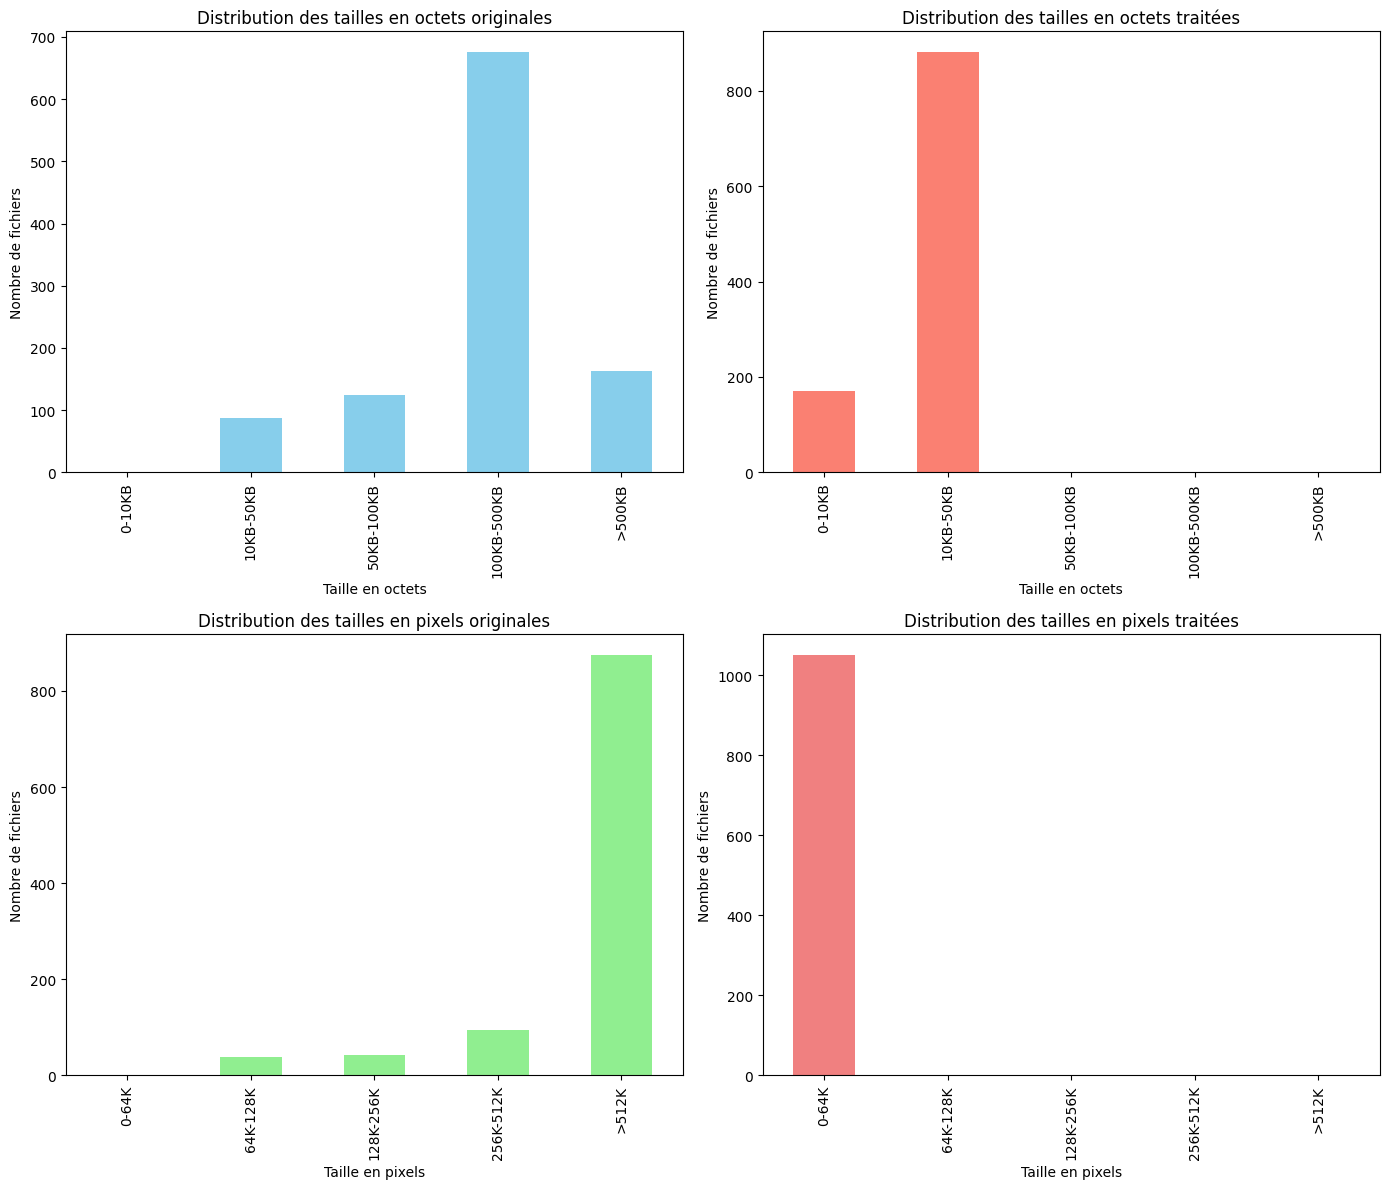

In [22]:
# Obtenir les tailles des fichiers dans les répertoires
original_sizes = get_file_sizes(path)
processed_sizes = get_file_sizes(new_path)

# Convertir en DataFrame
df_original = pd.DataFrame(original_sizes)
df_processed = pd.DataFrame(processed_sizes)

# Créer des bins pour la taille en octets
byte_bins = [0, 10**4, 5*10**4, 10**5, 5*10**5, float('inf')]
byte_labels = ['0-10KB', '10KB-50KB', '50KB-100KB', '100KB-500KB', '>500KB']

# Créer des bins pour la taille en pixels
pixel_bins = [0, 64*1024, 128*1024, 256*1024, 512*1024, float('inf')]
pixel_labels = ['0-64K', '64K-128K', '128K-256K', '256K-512K', '>512K']

# Ajouter des colonnes pour les bins
df_original['size_bin'] = pd.cut(df_original['size_bytes'], bins=byte_bins, labels=byte_labels)
df_processed['size_bin'] = pd.cut(df_processed['size_bytes'], bins=byte_bins, labels=byte_labels)
df_original['pixel_bin'] = pd.cut(df_original['size_pixels'], bins=pixel_bins, labels=pixel_labels)
df_processed['pixel_bin'] = pd.cut(df_processed['size_pixels'], bins=pixel_bins, labels=pixel_labels)

# Tracer les histogrammes
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Distribution des tailles en octets originales
df_original['size_bin'].value_counts().sort_index().plot(kind='bar', ax=axs[0, 0], color='skyblue')
axs[0, 0].set_title('Distribution des tailles en octets originales')
axs[0, 0].set_xlabel('Taille en octets')
axs[0, 0].set_ylabel('Nombre de fichiers')

# Distribution des tailles en octets traitées
df_processed['size_bin'].value_counts().sort_index().plot(kind='bar', ax=axs[0, 1], color='salmon')
axs[0, 1].set_title('Distribution des tailles en octets traitées')
axs[0, 1].set_xlabel('Taille en octets')
axs[0, 1].set_ylabel('Nombre de fichiers')

# Distribution des tailles en pixels originales
df_original['pixel_bin'].value_counts().sort_index().plot(kind='bar', ax=axs[1, 0], color='lightgreen')
axs[1, 0].set_title('Distribution des tailles en pixels originales')
axs[1, 0].set_xlabel('Taille en pixels')
axs[1, 0].set_ylabel('Nombre de fichiers')

# Distribution des tailles en pixels traitées
df_processed['pixel_bin'].value_counts().sort_index().plot(kind='bar', ax=axs[1, 1], color='lightcoral')
axs[1, 1].set_title('Distribution des tailles en pixels traitées')
axs[1, 1].set_xlabel('Taille en pixels')
axs[1, 1].set_ylabel('Nombre de fichiers')

plt.tight_layout()
plt.show()

Catégorie: Baby Care


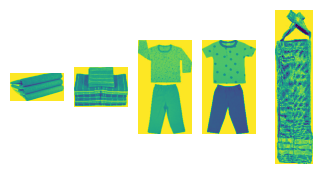

Catégorie: Beauty and Personal Care


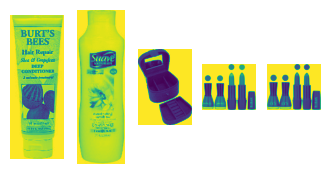

Catégorie: Computers


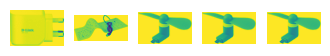

Catégorie: Home Decor & Festive Needs


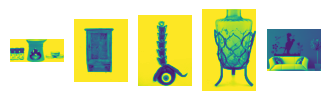

Catégorie: Home Furnishing


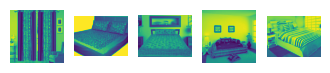

Catégorie: Kitchen & Dining


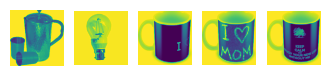

Catégorie: Watches


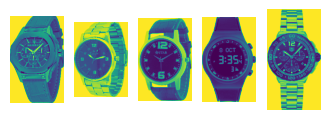

In [23]:
show_cat_img(df, new_path, 'cat_1', 5)

## Test : Détermination & affichage des descripteurs SIFT

In [24]:
list_photos = new_path + df_label['image']
print(len(list_photos))
print(list_photos[0])

1050
data/Images_process/55b85ea15a1536d46b7190ad6fff8ce7.jpg


### Descripteurs : filtres basiques

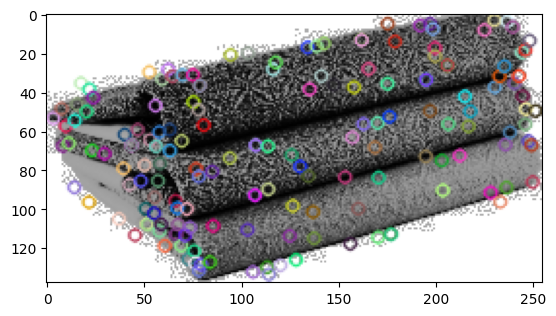

Descripteurs :  (171, 128)

[[  3.   1.   0. ...   0.   0.   0.]
 [  1.   7.  39. ...   0.   0.  41.]
 [ 11.  33.  19. ...   7.   9.  81.]
 ...
 [  0.   0.   0. ...   0.   0.   0.]
 [ 10.  11.   8. ...  14.  58.  38.]
 [124.  89.   7. ...   0.   7.  12.]]


In [25]:
# https://github.com/opencv/opencv/issues/16736
sift = cv2.SIFT_create()
image = cv2.imread(list_photos[1],0) # convert in gray
image = cv2.equalizeHist(image)   # equalize image histogram

kp, des = sift.detectAndCompute(image, None)
img=cv2.drawKeypoints(image,kp,image)
plt.imshow(img)
plt.show()
print("Descripteurs : ", des.shape)
print()
print(des)

### Descripteurs : ajout de filtres

In [26]:
sift_descriptors = 150
blur_kernel_size = 5

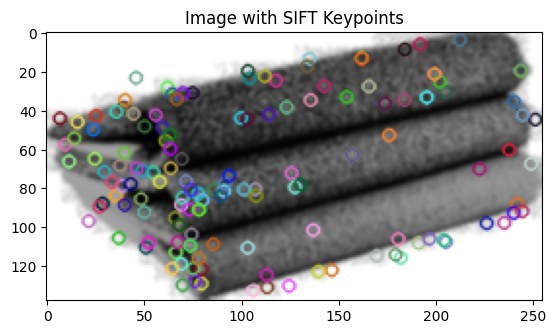

Descripteurs :  (150, 128)

[[ 46.  30.   1. ...   3.  60.  37.]
 [ 30. 177.  15. ...   0.   0.   0.]
 [  0.   8.  30. ...   0.   0.   0.]
 ...
 [ 40.  35.   2. ...   0.   0.   6.]
 [ 91.  35.   1. ...   7.   3.   6.]
 [  0.   0.   0. ...   0.   0.   3.]]


In [27]:
# Initialiser SIFT
sift = cv2.SIFT_create(sift_descriptors)

image = cv2.imread(list_photos[1], 0) 
image = cv2.equalizeHist(image) # Égaliser l'histogramme de l'image
image = image.astype(np.float32) / 255.0 # Normaliser l'image
image = cv2.GaussianBlur(image, (blur_kernel_size, blur_kernel_size), 0) # Appliquer un flou gaussien

# Convertir l'image en uint8 pour SIFT
image = (image * 255).astype(np.uint8)

# Détecter les points clés et calculer les descripteurs
kp, des = sift.detectAndCompute(image, None)

# Dessiner les points clés sur l'image
img = cv2.drawKeypoints(image, kp, image)

# Afficher l'image avec les points clés
plt.imshow(img, cmap='gray')
plt.title('Image with SIFT Keypoints')
plt.show()

# Afficher les informations sur les descripteurs
print("Descripteurs : ", des.shape)
print()
print(des)

## Modèlisation SIFT

### Extraction de features + réduction PCA + T-SNE

In [28]:
list_photos

0       data/Images_process/55b85ea15a1536d46b7190ad6f...
1       data/Images_process/7b72c92c2f6c40268628ec5f14...
2       data/Images_process/64d5d4a258243731dc7bbb1eef...
3       data/Images_process/d4684dcdc759dd9cdf41504698...
4       data/Images_process/6325b6870c54cd47be6ebfbffa...
                              ...                        
1045    data/Images_process/958f54f4c46b53c8a0a9b8167d...
1046    data/Images_process/fd6cbcc22efb6b761bd564c289...
1047    data/Images_process/5912e037d12774bb73a2048f35...
1048    data/Images_process/c3edc504d1b4f0ba6224fa53a4...
1049    data/Images_process/f2f027ad6a6df617c9f125173d...
Name: image, Length: 1050, dtype: object

In [29]:
# Décorateur pour mesurer le temps d'exécution
def timer_decorator(func):
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        start_time = time.time()  # Enregistrer le temps de début
        result = func(*args, **kwargs)  # Exécuter la fonction
        end_time = time.time()  # Enregistrer le temps de fin
        elapsed_time = end_time - start_time  # Calculer le temps écoulé
        print(f"Temps d'exécution de {func.__name__}: {elapsed_time:.4f} secondes")
        return result
    return wrapper

# Décorateur pour mesurer le temps total
def total_time_decorator(func):
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        wrapper.total_start_time = time.time()  # Enregistrer le temps de début total
        result = func(*args, **kwargs)  # Exécuter la fonction
        wrapper.total_end_time = time.time()  # Enregistrer le temps de fin total
        total_elapsed_time = wrapper.total_end_time - wrapper.total_start_time  # Calculer le temps total écoulé
        print(f"Temps total d'exécution: {total_elapsed_time:.4f} secondes")
        return result
    return wrapper

In [30]:
@total_time_decorator
def process_images(new_path, df_label, category, sift_descriptors):
    # Liste pour stocker tous les descripteurs
    all_descriptors = []
    image_features = []
    labels = []

    @timer_decorator
    def extract_sift_features(sift_descriptors):
        nonlocal all_descriptors, image_features, labels
        sift = cv2.SIFT_create(sift_descriptors)
        for index, row in df_label.iterrows():
            image_path = os.path.join(new_path, row['image'])
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            image = cv2.equalizeHist(image)   # equalize image histogram
            image = image.astype(np.float32) / 255.0   # Normaliser l'image
            blur_kernel_size = 5
            image = cv2.GaussianBlur(image, (blur_kernel_size, blur_kernel_size), 0) # Appliquer un flou gaussien
            
            # Convertir l'image en uint8 pour SIFT
            image = (image * 255).astype(np.uint8)
            _, descriptors = sift.detectAndCompute(image, None)
            if descriptors is not None:
                all_descriptors.append(descriptors)
                image_features.append(descriptors.mean(axis=0))  # Utiliser la moyenne comme feature
                labels.append(row[category])

    @timer_decorator
    def create_clusters():
        nonlocal all_descriptors
        # Concaténer tous les descripteurs en un seul tableau
        all_descriptors = np.concatenate(all_descriptors, axis=0)
        # Créer des clusters de descripteurs avec K-means
        num_clusters = 50
        kmeans = KMeans(n_clusters=num_clusters)
        kmeans.fit(all_descriptors)
        return kmeans, num_clusters

    @timer_decorator
    def create_image_histograms(kmeans, num_clusters):
        nonlocal all_descriptors, image_features
        visual_words = kmeans.predict(all_descriptors)
        image_histograms = np.zeros((len(image_features), num_clusters), dtype=np.float32)
        start = 0
        for i, descriptors in enumerate(all_descriptors):
            length = len(descriptors)
            histogram = np.bincount(visual_words[start:start + length], minlength=num_clusters)
            if i < len(image_features):  # Vérifier que l'index est valide
                image_histograms[i] = histogram
            start += length
        return image_histograms

    @timer_decorator
    def reduce_dimensions(image_histograms):
        # Réduction de dimension avec PCA
        pca = PCA(n_components=50)
        reduced_features = pca.fit_transform(image_histograms)
        # Réduction de dimension avec t-SNE pour la visualisation
        tsne = TSNE(n_components=2)
        tsne_results = tsne.fit_transform(reduced_features)
        return tsne_results

    @timer_decorator
    def plot_results(tsne_results, labels):
        # Visualisation des résultats t-SNE
        plt.figure(figsize=(10, 6))
        unique_labels = np.unique(labels)
        colors = plt.cm.get_cmap("hsv", len(unique_labels))
        for i, label in enumerate(unique_labels):
            idx = np.array(labels) == label
            plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1], label=label, color=colors(i), s=5)
        plt.title('t-SNE Visualization of Image Features with Classes')
        plt.xlabel('t-SNE Component 1')
        plt.ylabel('t-SNE Component 2')
        plt.legend()
        plt.show()

    # Exécuter les étapes
    extract_sift_features(sift_descriptors)
    kmeans, num_clusters = create_clusters()
    image_histograms = create_image_histograms(kmeans, num_clusters)
    tsne_results = reduce_dimensions(image_histograms)
    plot_results(tsne_results, labels)

### Exécution SIFT > PCA > T-SNE

#### 1ère catégorie, 200 descripteurs /img

Temps d'exécution de extract_sift_features: 12.5009 secondes
Temps d'exécution de create_clusters: 16.7703 secondes
Temps d'exécution de create_image_histograms: 0.3797 secondes
Temps d'exécution de reduce_dimensions: 3.0994 secondes


/tmp/ipykernel_494738/3491919530.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("hsv", len(unique_labels))


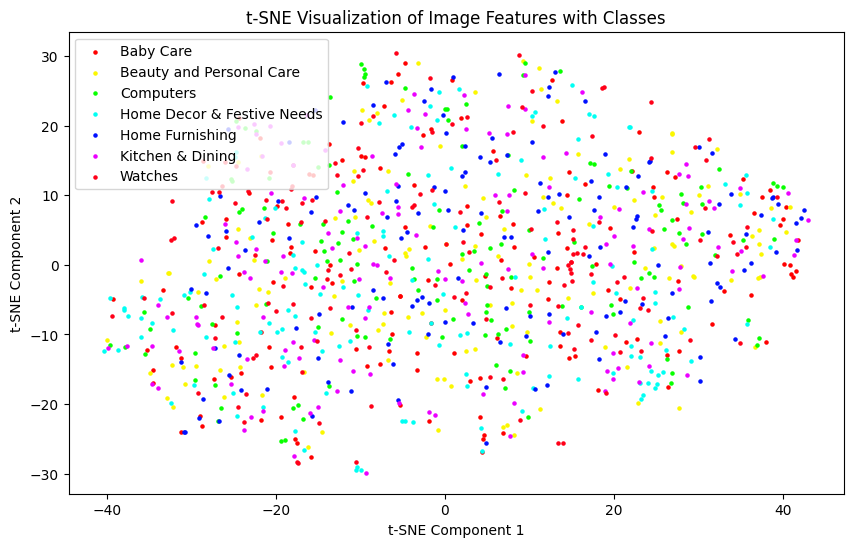

Temps d'exécution de plot_results: 0.3254 secondes
Temps total d'exécution: 33.0772 secondes


In [31]:
# Appeler la fonction principale
process_images(new_path, df_label, 'cat_1', 200)

#### 2ère catégorie, 200 descripteurs /img

In [32]:
df_label_cat2 = df[['image', 'description','cat_2']].copy()

le = preprocessing.LabelEncoder()
df_label_cat2["label"] = le.fit_transform(df_label_cat2["cat_2"])

df_label_cat2.head(3)

,image,description,cat_2,label
0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,Key Features of Elegance Polyester Multicolor ...,Curtains & Accessories,19
1,7b72c92c2f6c40268628ec5f14c6d590.jpg,Specifications of Sathiyas Cotton Bath Towel (...,Baby Bath & Skin,1
2,64d5d4a258243731dc7bbb1eef49ad74.jpg,Key Features of Eurospa Cotton Terry Face Towe...,Baby Bath & Skin,1


Temps d'exécution de extract_sift_features: 11.1759 secondes
Temps d'exécution de create_clusters: 11.9303 secondes
Temps d'exécution de create_image_histograms: 0.4112 secondes
Temps d'exécution de reduce_dimensions: 3.0954 secondes


/tmp/ipykernel_494738/3491919530.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("hsv", len(unique_labels))


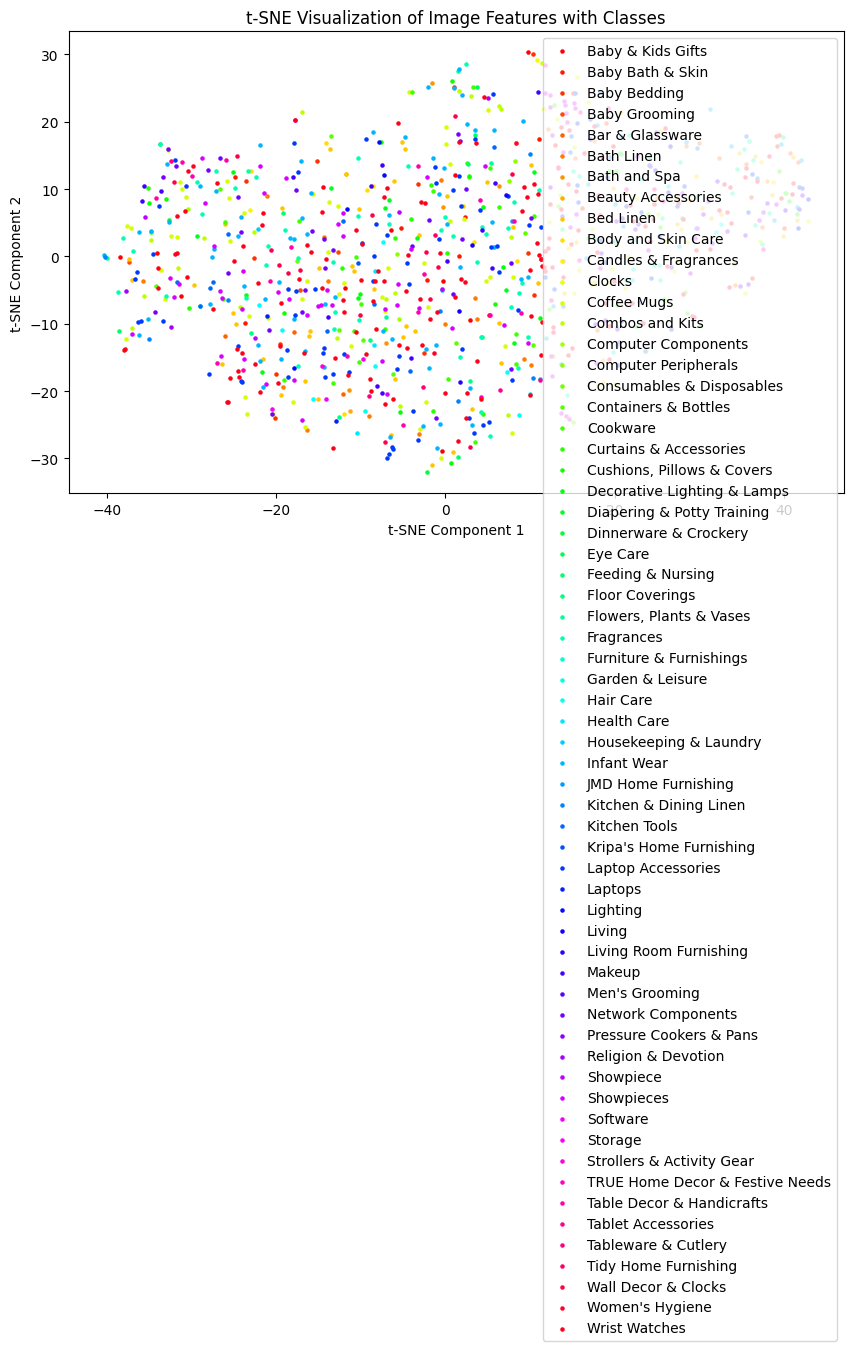

Temps d'exécution de plot_results: 1.3487 secondes
Temps total d'exécution: 27.9629 secondes


In [33]:
process_images(new_path, df_label_cat2, 'cat_2', 200)

#### Conclusion SIFT

Résultats => patchwork de points : peu de résultats interprétables après une première passe.

En l'état non utilisable.

# Modèle CNN : étude de faisabilité

## VGG16

### Création du modèle pré-entraîné

In [34]:
base_model = VGG16()
model = Model(inputs=base_model.inputs, outputs=base_model.layers[-2].output)

print(model.summary())

2025-04-03 10:59:38.887734: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-04-03 10:59:39.067869: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 411041792 exceeds 10% of free system memory.
2025-04-03 10:59:39.180206: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 411041792 exceeds 10% of free system memory.
2025-04-03 10:59:39.258665: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 411041792 exceeds 10% of free system memory.
2025-04-03 10:59:40.462300: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 411041792 exceeds 10% of free system memory.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

None


### Création des features des images

In [35]:
path

'data/Images/'

In [36]:
images_features = []
i=0 
for image_file in df["image"] :
    if i%100 == 0 : print(i)
    i +=1
    image = load_img(path + image_file, target_size=(224, 224))
    image = img_to_array(image) 
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)
    images_features.append(model.predict(image, verbose=0)[0]) # predict from pretrained model

images_features = np.asarray(images_features)
images_features.shape

0


/home/mijka/.pyenv/versions/3.9.7/lib/python3.9/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


100
200
300
400
500
600


/home/mijka/.pyenv/versions/3.9.7/lib/python3.9/site-packages/PIL/Image.py:3406: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


700
800
900
1000


(1050, 4096)

### Réduction dimension et analyse

#### Réduction de dimension PCA

In [37]:
print(images_features.shape)
pca = decomposition.PCA(n_components=0.99)
feat_pca= pca.fit_transform(images_features)
print(feat_pca.shape)

(1050, 4096)
(1050, 803)


#### Réduction de dimension T-SNE et affichage des images selon vraies classes

In [60]:
temps1 = time.time()

tsne = manifold.TSNE(n_components=2, perplexity=30, max_iter=2000, init='random', random_state=6)
X_tsne = tsne.fit_transform(feat_pca)

duration1=time.time()-temps1
print("temps de T-SNE : ", "%15.2f" % duration1, "secondes")

temps de T-SNE :             5.28 secondes


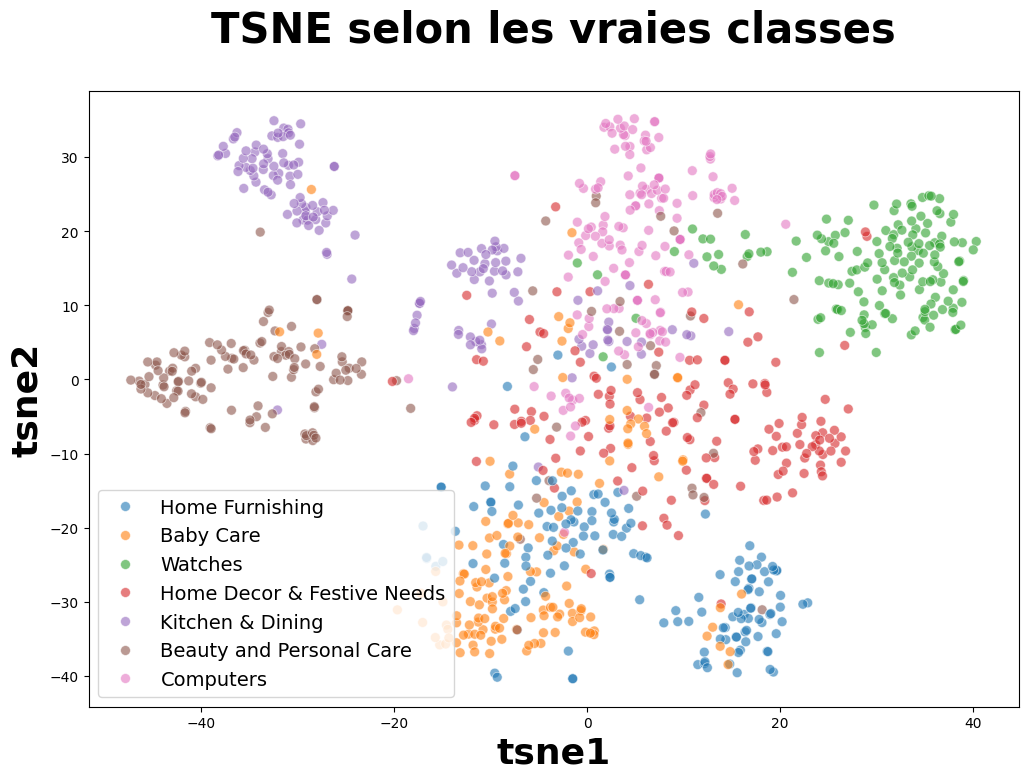

In [61]:
df_tsne = pd.DataFrame(X_tsne, columns=['tsne1', 'tsne2'])
df_tsne["class"] = df["cat_1"]

class_count = len(df_tsne["class"].unique())

plt.figure(figsize=(12,8))
sns.scatterplot(
    x="tsne1", y="tsne2",
    hue="class",
    palette=sns.color_palette('tab10', n_colors=class_count), s=50, alpha=0.6,
    data=df_tsne,
    legend="brief")

plt.title('TSNE selon les vraies classes', fontsize = 30, pad = 35, fontweight = 'bold')
plt.xlabel('tsne1', fontsize = 26, fontweight = 'bold')
plt.ylabel('tsne2', fontsize = 26, fontweight = 'bold')
plt.legend(prop={'size': 14}) 

plt.show()

#### Création de clusters à partir du T-SNE et affichage des images selon clusters

In [66]:
df_label.head(2)

,image,description,cat_1,label
0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,Key Features of Elegance Polyester Multicolor ...,Home Furnishing,4
1,7b72c92c2f6c40268628ec5f14c6d590.jpg,Specifications of Sathiyas Cotton Bath Towel (...,Baby Care,0


In [72]:
class_count

7

In [70]:
cls = cluster.KMeans(n_clusters=class_count, n_init=100)
cls.fit(X_tsne)

KMeans(n_clusters=7, n_init=100)

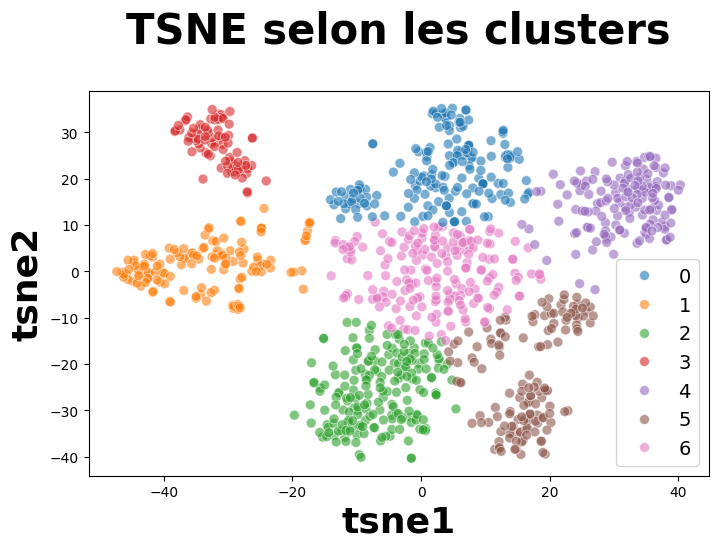

ARI :  0.4540642100917925


In [71]:
df_tsne["cluster"] = cls.labels_

plt.figure(figsize=(8,5))
sns.scatterplot(
    x="tsne1", y="tsne2",
    hue="cluster",
    palette=sns.color_palette('tab10', n_colors=class_count), s=50, alpha=0.6,
    data=df_tsne,
    legend="brief")

plt.title('TSNE selon les clusters', fontsize = 30, pad = 35, fontweight = 'bold')
plt.xlabel('tsne1', fontsize = 26, fontweight = 'bold')
plt.ylabel('tsne2', fontsize = 26, fontweight = 'bold')
plt.legend(prop={'size': 14}) 

plt.show()

labels = df_label["label"]
print("ARI : ", metrics.adjusted_rand_score(labels, cls.labels_))

In [73]:
df_label["label"].unique()

array([4, 0, 6, 3, 5, 1, 2])

In [161]:
labels_info = df_label[["label","cat_1"]]\
            .drop_duplicates().sort_values(by=['label'], ascending=True)\
            .reset_index(drop=True)

print(labels_info.to_string(index=False))

 label                      cat_1
     0                  Baby Care
     1   Beauty and Personal Care
     2                  Computers
     3 Home Decor & Festive Needs
     4            Home Furnishing
     5           Kitchen & Dining
     6                    Watches


In [165]:
labels_info_tsne = df_tsne[["cluster","class"]]\
            .drop_duplicates().sort_values(by=['cluster'], ascending=True)\
            .reset_index(drop=True)

print(labels_info.to_string(index=False))

 label                      cat_1
     0                  Baby Care
     1   Beauty and Personal Care
     2                  Computers
     3 Home Decor & Festive Needs
     4            Home Furnishing
     5           Kitchen & Dining
     6                    Watches


In [163]:
# Analyse d'image "Computers" affectées au cluster 4 "Home Furnishing"

list_computers_0 = [i for i in range(len(df["image"])) \
                if (df.iloc[i]['cat_1']=='Computers') and (df_tsne.iloc[i]['cluster']== 4)]
id_to_show = list_computers_0[0]

print(len(list_computers_0))
print(id_to_show)

1
639


tsne1      20.577393
tsne2      20.931189
class      Computers
cluster            4
Name: 639, dtype: object


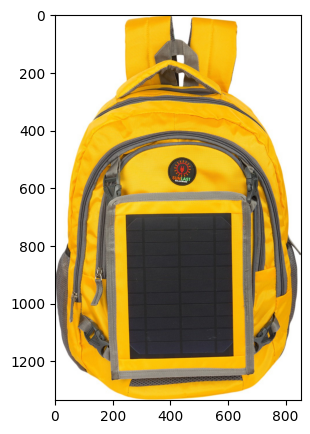

In [164]:
# Affichage image "Computers" considérée comme "Home Furnishing"
print(df_tsne.iloc[id_to_show])
fig = plt.figure(figsize = (8, 5))
# plt.subplot(130 + 1 + i)
filename = path + df["image"][id_to_show]
image = imread(filename)
plt.imshow(image)
plt.show()

#### Analyse par classes

In [130]:
conf_mat = metrics.confusion_matrix(labels, cls.labels_)
print(conf_mat)

[[  1   3 109   1   1   8  27]
 [  9 117   4   1   1   6  12]
 [113   1   1   0   1   0  34]
 [  5   1   3   0   8  56  77]
 [  0   0  75   0   0  71   4]
 [ 32  10   0  78   0   0  30]
 [ 13   0   0   0 135   0   2]]


In [131]:
def conf_mat_transform(y_true,y_pred) :
    conf_mat = metrics.confusion_matrix(y_true,y_pred)
    
    corresp = np.argmax(conf_mat, axis=0)
    print ("Correspondance des clusters : ", corresp)
    # y_pred_transform = np.apply_along_axis(correspond_fct, 1, y_pred)
    labels = pd.Series(y_true, name="y_true").to_frame()
    labels['y_pred'] = y_pred
    labels['y_pred_transform'] = labels['y_pred'].apply(lambda x : corresp[x]) 
    
    return labels['y_pred_transform']

In [132]:
cls_labels_transform = conf_mat_transform(labels, cls.labels_)
conf_mat = metrics.confusion_matrix(labels, cls_labels_transform)
print(conf_mat)
print()
print(metrics.classification_report(labels, cls_labels_transform))

Correspondance des clusters :  [2 1 0 5 6 4 3]
[[109   3   1  27   8   1   1]
 [  4 117   9  12   6   1   1]
 [  1   1 113  34   0   0   1]
 [  3   1   5  77  56   0   8]
 [ 75   0   0   4  71   0   0]
 [  0  10  32  30   0  78   0]
 [  0   0  13   2   0   0 135]]

              precision    recall  f1-score   support

           0       0.57      0.73      0.64       150
           1       0.89      0.78      0.83       150
           2       0.65      0.75      0.70       150
           3       0.41      0.51      0.46       150
           4       0.50      0.47      0.49       150
           5       0.97      0.52      0.68       150
           6       0.92      0.90      0.91       150

    accuracy                           0.67      1050
   macro avg       0.70      0.67      0.67      1050
weighted avg       0.70      0.67      0.67      1050



In [171]:
list_labels = labels_info.cat_1.unique()
list_labels

array(['Baby Care', 'Beauty and Personal Care', 'Computers',
       'Home Decor & Festive Needs', 'Home Furnishing',
       'Kitchen & Dining', 'Watches'], dtype=object)

In [172]:
concatenated_string = ''.join(str(i) for i in range(1, class_count+1))

print(concatenated_string)

1234567


<Axes: >

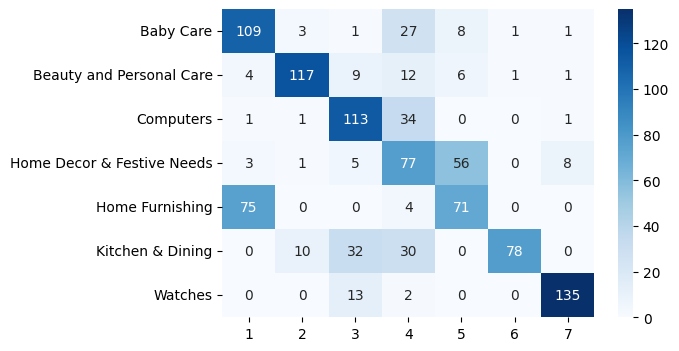

In [173]:
df_cm = pd.DataFrame(conf_mat, index = [label for label in list_labels],
                  columns = [i for i in concatenated_string])
plt.figure(figsize = (6,4))
sns.heatmap(df_cm, annot=True, fmt='d', cmap="Blues")

### Classification Supervisée

In [182]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [179]:
path

'data/Images/'

In [183]:
# Paramètres pour les générateurs
img_height, img_width = 224, 224
batch_size = 32 

# Créer les générateurs pour les ensembles d'entraînement, de validation et de test
train_datagen = ImageDataGenerator(
                                rescale=1./255,
                                rotation_range=40,
                                width_shift_range=0.2,
                                height_shift_range=0.2,
                                shear_range=0.2,
                                zoom_range=0.2,
                                horizontal_flip=True,
                                fill_mode='nearest')
 
val_test_datagen = ImageDataGenerator(rescale=1./255) # Pas d'augmentation pour la validation et le test

In [185]:
path 

'data/Images/'

In [186]:
cnn_path = 'data/CNN_Images/'

In [187]:
# Charger les données
os.makedirs(cnn_path + '/train', exist_ok=True)
os.makedirs(cnn_path + '/validation', exist_ok=True)
os.makedirs(cnn_path + '/test', exist_ok=True)


train_generator = train_datagen.flow_from_directory(
    cnn_path + '/train',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical')

validation_generator = val_test_datagen.flow_from_directory(
    cnn_path + '/validation',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical')

test_generator = val_test_datagen.flow_from_directory(
    cnn_path + '/test',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False)  # Ne pas mélanger les données de test

# Afficher les classes
print("Classes : ", train_generator.class_indices)

Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.
Classes :  {}


In [ ]:
from keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

datagen = ImageDataGenerator(
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest')

img = load_img('data/train/cats/cat.0.jpg')  # this is a PIL image
x = img_to_array(img)  # this is a Numpy array with shape (3, 150, 150)
x = x.reshape((1,) + x.shape)  # this is a Numpy array with shape (1, 3, 150, 150)

# the .flow() command below generates batches of randomly transformed images
# and saves the results to the `preview/` directory
i = 0
for batch in datagen.flow(x, batch_size=1,
                          save_to_dir='preview', save_prefix='cat', save_format='jpeg'):
    i += 1
    if i > 20:
        break  # otherwise the generator would loop indefinitely


In [ ]:
batch_size = 16

# this is the augmentation configuration we will use for training
train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)

# this is the augmentation configuration we will use for testing:
# only rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# this is a generator that will read pictures found in
# subfolers of 'data/train', and indefinitely generate
# batches of augmented image data
train_generator = train_datagen.flow_from_directory(
        'data/train',  # this is the target directory
        target_size=(150, 150),  # all images will be resized to 150x150
        batch_size=batch_size,
        class_mode='binary')  # since we use binary_crossentropy loss, we need binary labels

# this is a similar generator, for validation data
validation_generator = test_datagen.flow_from_directory(
        'data/validation',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')


## Comparaison 3 modèles CNN : VGG16 / ResNet50V2 / NASNetMobile

In [ ]:
# liste modèles : https://keras.io/api/applications/

In [41]:
#ResNet50V2

#NASNetMobile

### Préparation boucle

In [40]:
def extract_features_and_visualize(model_name, preprocess_func, df, path):
    # Charger le modèle
    if model_name == "VGG16":
        base_model = VGG16(weights='imagenet')
    elif model_name == "ResNet50V2":
        base_model = ResNet50V2(weights='imagenet')
    elif model_name == "NASNetMobile":
        base_model = NASNetMobile(weights='imagenet')
    else:
        raise ValueError("Modèle non supporté")

    model = Model(inputs=base_model.inputs, outputs=base_model.layers[-2].output)

    print(model.summary())
    images_features = []
    i = 0
    for image_file in df["image"]:
        image_path = os.path.join(path, image_file)
        if i % 100 == 0:
            print(i)
        i += 1
        if os.path.exists(image_path):
            image = load_img(image_path, target_size=(224, 224))
            image = img_to_array(image)
            image = np.expand_dims(image, axis=0)
            image = preprocess_func(image)
            images_features.append(model.predict(image, verbose=0)[0])
        else:
            print(f"Image non trouvée: {image_path}")

    images_features = np.asarray(images_features)
    print(images_features.shape)

    pca = decomposition.PCA(n_components=0.99)
    feat_pca = pca.fit_transform(images_features)
    print(feat_pca.shape)

    temps1 = time.time()
    tsne = manifold.TSNE(n_components=2, perplexity=30, n_iter=2000, init='random', random_state=6)
    X_tsne = tsne.fit_transform(feat_pca)
    duration1 = time.time() - temps1
    print("Temps de T-SNE : ", "%15.2f" % duration1, "secondes")

    df_tsne = pd.DataFrame(X_tsne, columns=['tsne1', 'tsne2'])
    df_tsne["class"] = df["cat_1"]

    return df_tsne, model_name

### Exécution 

In [41]:
# Appeler la fonction pour chaque modèle et stocker les résultats
tsne_results = []
models = [
    ("VGG16", vgg16.preprocess_input),
    ("ResNet50V2", resnet_v2.preprocess_input),
    ("NASNetMobile", nasnet.preprocess_input)
]

for model_name, preprocess_func in models:
    tsne_results.append(extract_features_and_visualize(model_name, preprocess_func, df, path))

2025-04-03 11:04:20.578859: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 411041792 exceeds 10% of free system memory.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

...

100
200
300
400
500
600


/home/mijka/.pyenv/versions/3.9.7/lib/python3.9/site-packages/PIL/Image.py:3406: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


700
800
900
1000
(1050, 1056)
(1050, 539)


/home/mijka/.pyenv/versions/3.9.7/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Temps de T-SNE :             5.82 secondes


### Résultats

In [46]:
class_count = len(df_tsne["class"].unique())

def print_tsnes(tsne_results, class_count, order='horizontal'):
    # Déterminer la disposition des sous-graphiques
    if order == 'horizontal':
        nrows, ncols = 1, len(tsne_results)
        figsize = (18, 6)
    elif order == 'vertical':
        nrows, ncols = len(tsne_results), 1
        figsize = (8, 18)
    else:
        raise ValueError("L'argument 'order' doit être 'horizontal' ou 'vertical'.")

    # Créer la figure
    plt.figure(figsize=figsize)

    for i, (df_tsne, model_name) in enumerate(tsne_results):
        plt.subplot(nrows, ncols, i + 1)
        sns.scatterplot(
            x="tsne1", y="tsne2",
            hue="class",
            palette=sns.color_palette('tab10', n_colors=class_count), s=50, alpha=0.6,
            data=df_tsne,
            legend="brief"
        )
        plt.title(f'TSNE avec {model_name}', fontsize=20, pad=20, fontweight='bold')
        plt.xlabel('tsne1', fontsize=16, fontweight='bold')
        plt.ylabel('tsne2', fontsize=16, fontweight='bold')
        plt.legend(prop={'size': 10})

    plt.tight_layout()
    plt.show()

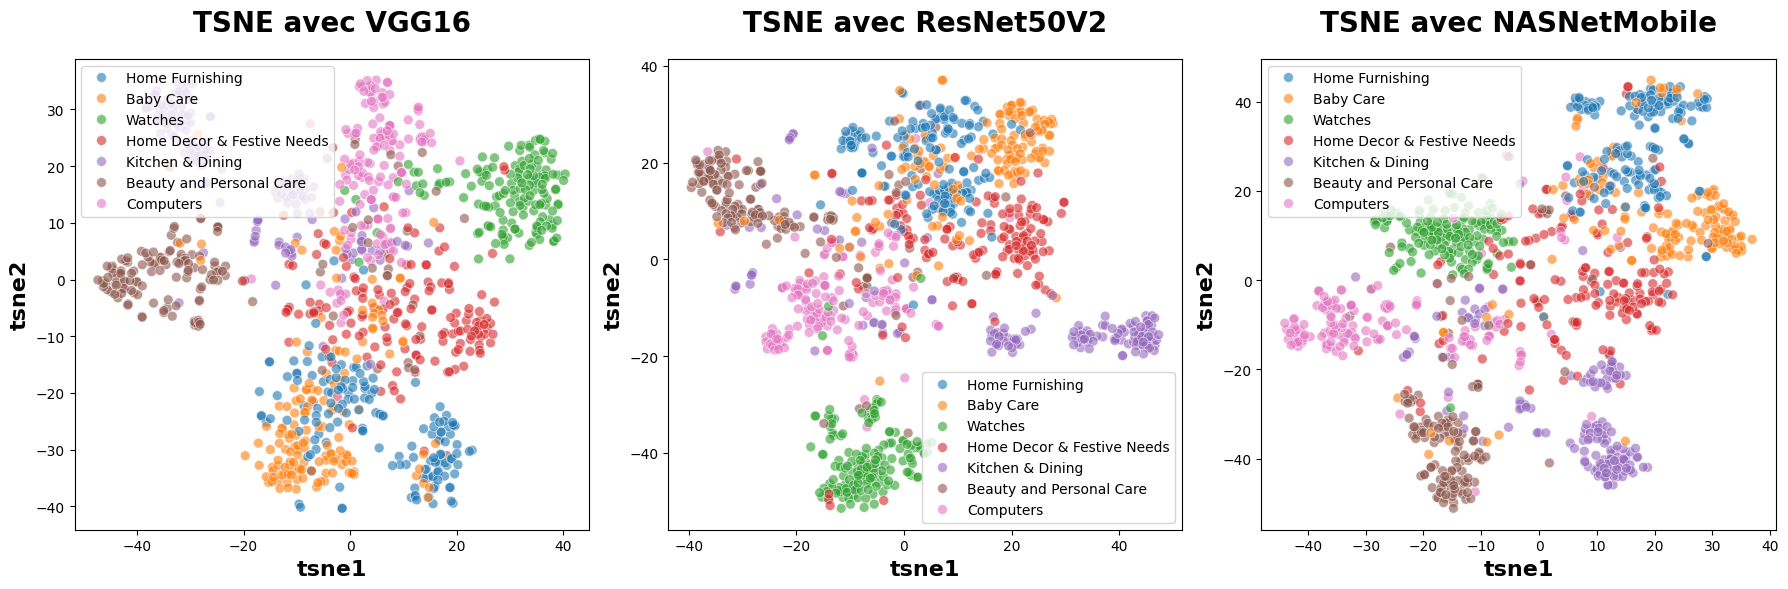

In [49]:
print_tsnes(tsne_results, class_count)

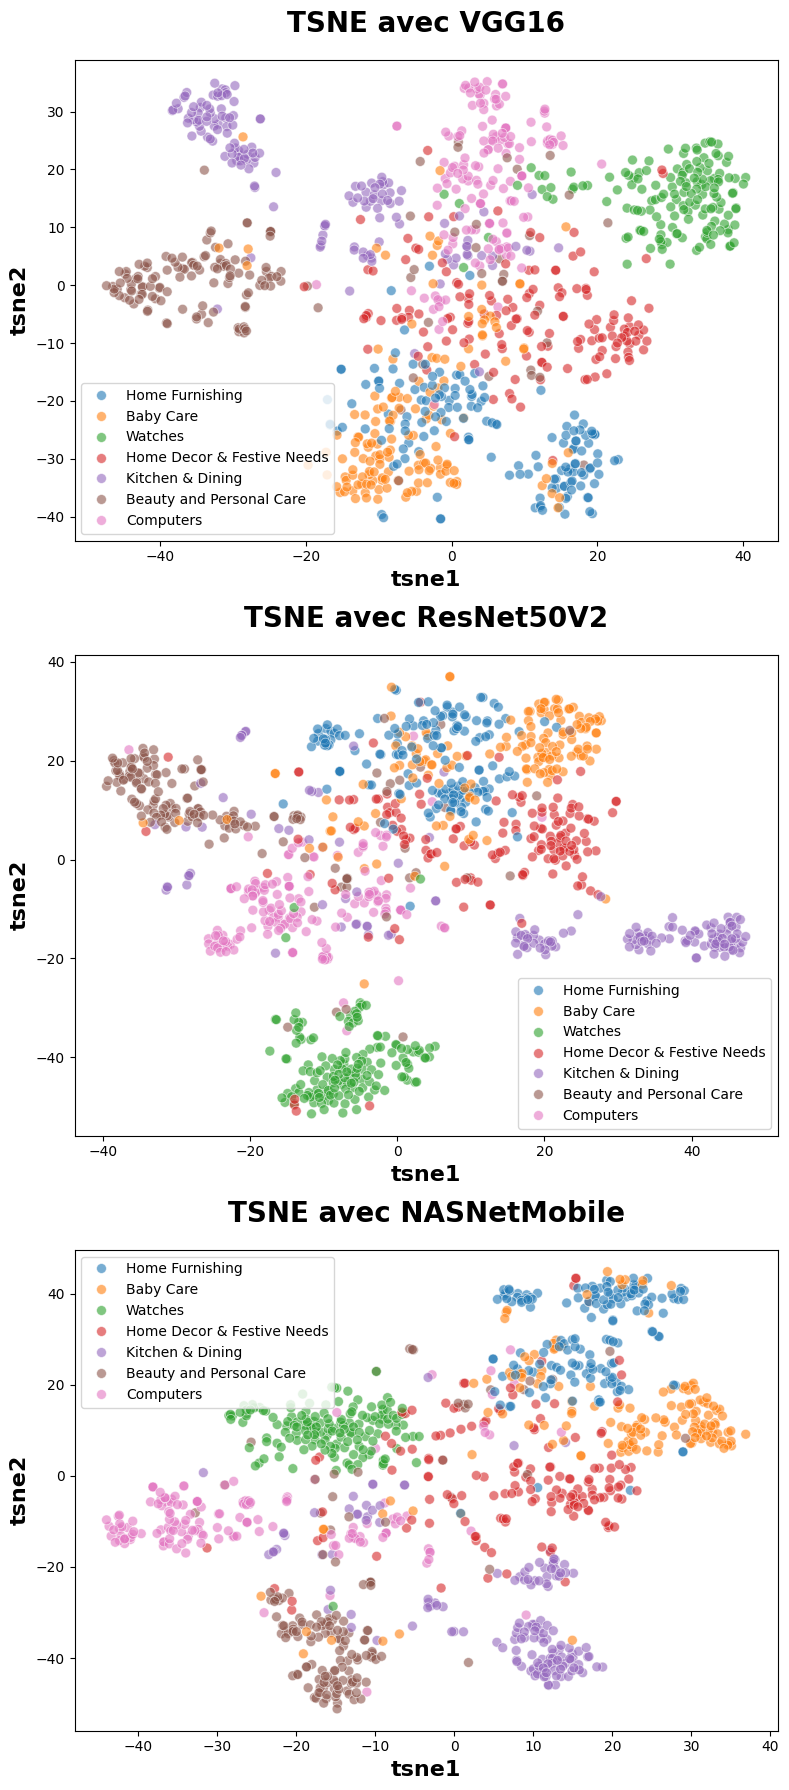

In [51]:
print_tsnes(tsne_results, class_count, 'vertical')

=> 